# Hourly Revenue Prediction Model

## Project Objective

The goal of this notebook is to extend the pizza sales analytics project into a data science task by building a machine learning model to predict hourly revenue.

The earlier SQL and Power BI analysis showed that pizza sales are strongly influenced by time-based patterns such as weekday, hour of day, lunch periods, and weekend dinner periods. Based on those findings, this notebook explores whether hourly revenue can be predicted using historical sales patterns.

This model can support business decisions such as:

- Staff scheduling
- Ingredient preparation
- Peak-hour planning
- Promotion timing
- Demand forecasting

## Machine Learning Problem Definition

This is a supervised regression problem.

The target variable is:

- `hourly_revenue`

The model will learn from historical hourly sales data and predict expected revenue for future hourly periods.

The prediction task is useful because restaurants need to estimate demand before or during operating periods to plan staff, inventory, and promotions more effectively.

## Data Loading and Initial Preparation

The original dataset is transaction-level data, where each row represents a pizza item sold as part of an order.

For revenue prediction, transaction-level rows are not the best modelling unit because the business question is about demand during each time period. Therefore, the data will be aggregated to hourly level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/pizza_sales.csv")

df["order_date"] = pd.to_datetime(df["order_date"], dayfirst=True)
df["order_time"] = pd.to_datetime(df["order_time"], format="mixed").dt.time

df["month"] = df["order_date"].dt.month
df["weekday"] = df["order_date"].dt.day_name()
df["weekday_num"] = df["order_date"].dt.weekday
df["hour"] = pd.to_datetime(df["order_time"].astype(str), format="mixed").dt.hour

df.head()

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,month,weekday,weekday_num,hour
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,1,Thursday,3,11
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,1,Thursday,3,11
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,1,Thursday,3,11
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,1,Thursday,3,11
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,1,Thursday,3,11


## Aggregating Sales to Hourly Level

The original dataset contains individual pizza sales. To predict demand by time period, the data is grouped by date and hour.

Each row in the new dataset represents one operating hour on a specific date.

For each date-hour combination, the total revenue is calculated as the prediction target.

In [2]:
hourly_df = (
    df.groupby(["order_date", "month", "weekday", "weekday_num", "hour"])
      .agg(hourly_revenue=("total_price", "sum"))
      .reset_index()
)

hourly_df["datetime"] = pd.to_datetime(
    hourly_df["order_date"].astype(str) + " " + hourly_df["hour"].astype(str) + ":00:00"
)

hourly_df = hourly_df.sort_values("datetime").reset_index(drop=True)

hourly_df.head()

,order_date,month,weekday,weekday_num,hour,hourly_revenue,datetime
0,2015-01-01,1,Thursday,3,11,105.25,2015-01-01 11:00:00
1,2015-01-01,1,Thursday,3,12,263.25,2015-01-01 12:00:00
2,2015-01-01,1,Thursday,3,13,577.20,2015-01-01 13:00:00
3,2015-01-01,1,Thursday,3,14,246.00,2015-01-01 14:00:00
4,2015-01-01,1,Thursday,3,15,230.25,2015-01-01 15:00:00


## Baseline Modelling Approach

Before building a more complex model, a simple baseline model is created using only basic time-based features:

- Month
- Weekday number
- Hour of day

This baseline is important because it gives a starting point for comparison. If a more advanced model cannot perform better than this simple model, then the additional complexity is not useful.

The baseline model also represents a realistic forecasting scenario because these features are known before the sales period begins.

In [3]:
baseline_features = ["month", "weekday_num", "hour"]
target = "hourly_revenue"

hourly_df = hourly_df.sort_values("datetime")

split_index = int(len(hourly_df) * 0.8)

train = hourly_df.iloc[:split_index]
test = hourly_df.iloc[split_index:]

X_train = train[baseline_features]
y_train = train[target]

X_test = test[baseline_features]
y_test = test[target]

## Baseline Model Training

Two baseline models are tested:

1. Linear Regression
2. Random Forest Regressor

Linear Regression is used as a simple interpretable baseline. Random Forest is used because it can capture non-linear relationships between time features and revenue.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

baseline_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    baseline_results.append([name, mae, rmse, r2])

baseline_results_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

baseline_results_df

,Model,MAE,RMSE,R2
0,Linear Regression,100.609795,129.393555,0.064205
1,Random Forest,93.470966,122.254545,0.164617


## Baseline Model Results

The baseline model was trained using only simple time-based features: month, weekday number, and hour of day.

Two models were tested:

* Linear Regression
* Random Forest Regressor

Random Forest performed better than Linear Regression, with a lower MAE and RMSE and a higher R² score.

The Random Forest model achieved:

* MAE: 93.47
* RMSE: 122.25
* R² Score: 0.165

This means the model’s average prediction error is approximately $93 per hourly revenue period. The R² score of 0.165 means the model explains around 16.5% of the variation in hourly revenue.

Although Random Forest performed better than Linear Regression, the overall performance is still limited. This shows that basic time features such as month, weekday, and hour are not enough to fully explain hourly revenue patterns.

This baseline result is useful because it provides a benchmark. The next step is to improve the model using feature engineering based on business understanding and historical demand patterns.


## Why Feature Engineering Is Needed

The baseline model showed that simple time features provide only limited predictive power. However, the earlier SQL and Power BI analysis showed stronger business patterns, such as lunch peaks, weekend dinner demand, and differences between weekdays and weekends.

To help the model capture these patterns more effectively, additional features will be created.

The improved model will include:

- Weekend indicator
- Lunch-hour indicator
- Dinner-hour indicator
- Cyclical time features
- Lag revenue features
- Rolling average revenue features

These features are designed to help the model understand both recurring time patterns and recent demand behaviour.

In [5]:
# Business period features
hourly_df["is_weekend"] = hourly_df["weekday_num"].isin([5, 6]).astype(int)
hourly_df["is_lunch_hour"] = hourly_df["hour"].between(11, 14).astype(int)
hourly_df["is_dinner_hour"] = hourly_df["hour"].between(17, 20).astype(int)

# Cyclical time features
hourly_df["hour_sin"] = np.sin(2 * np.pi * hourly_df["hour"] / 24)
hourly_df["hour_cos"] = np.cos(2 * np.pi * hourly_df["hour"] / 24)

hourly_df["weekday_sin"] = np.sin(2 * np.pi * hourly_df["weekday_num"] / 7)
hourly_df["weekday_cos"] = np.cos(2 * np.pi * hourly_df["weekday_num"] / 7)

hourly_df["month_sin"] = np.sin(2 * np.pi * hourly_df["month"] / 12)
hourly_df["month_cos"] = np.cos(2 * np.pi * hourly_df["month"] / 12)

# Historical demand features
hourly_df["revenue_lag_1"] = hourly_df["hourly_revenue"].shift(1)
hourly_df["revenue_lag_24"] = hourly_df["hourly_revenue"].shift(24)

hourly_df["rolling_mean_3"] = (
    hourly_df["hourly_revenue"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

hourly_df["rolling_mean_7"] = (
    hourly_df["hourly_revenue"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

hourly_df.head()

,order_date,month,weekday,weekday_num,hour,hourly_revenue,datetime,is_weekend,is_lunch_hour,is_dinner_hour,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,revenue_lag_1,revenue_lag_24,rolling_mean_3,rolling_mean_7
0,2015-01-01,1,Thursday,3,11,105.25,2015-01-01 11:00:00,0,1,0,2.588190e-01,-0.965926,0.433884,-0.900969,0.5,0.866025,NaN,NaN,NaN,NaN
1,2015-01-01,1,Thursday,3,12,263.25,2015-01-01 12:00:00,0,1,0,1.224647e-16,-1.000000,0.433884,-0.900969,0.5,0.866025,105.25,NaN,NaN,NaN
2,2015-01-01,1,Thursday,3,13,577.20,2015-01-01 13:00:00,0,1,0,-2.588190e-01,-0.965926,0.433884,-0.900969,0.5,0.866025,263.25,NaN,NaN,NaN
3,2015-01-01,1,Thursday,3,14,246.00,2015-01-01 14:00:00,0,1,0,-5.000000e-01,-0.866025,0.433884,-0.900969,0.5,0.866025,577.20,NaN,315.233333,NaN
4,2015-01-01,1,Thursday,3,15,230.25,2015-01-01 15:00:00,0,0,0,-7.071068e-01,-0.707107,0.433884,-0.900969,0.5,0.866025,246.00,NaN,362.150000,NaN


## Why Cyclical Time Features Are Used

Time variables such as hour, weekday, and month are cyclical.

For example, 11 PM and 12 AM are close in real life, but as raw numbers, 23 and 0 appear far apart. Similarly, Sunday and Monday are close in weekly order, but their raw numeric values may not show that relationship clearly.

Sine and cosine transformations help the model understand repeating time patterns more naturally.

## Why Lag and Rolling Features Are Used

Sales demand often depends on recent sales behaviour.

For example, if revenue was high in the previous hour or similar recent periods, the next period may also show stronger demand. Lag features help the model capture this recent demand signal.

Rolling averages smooth short-term fluctuations and help the model understand the general recent trend rather than reacting only to one previous value.

To avoid data leakage, lag and rolling features are created using only past revenue values.

## Improved Model Training

After feature engineering, multiple regression models are trained and compared.

The models tested are:

- Linear Regression
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor
- Hist Gradient Boosting Regressor

The same chronological train-test split is used so that the model is evaluated on later data, similar to a real forecasting scenario.

In [6]:
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

features = [
    "is_weekend",
    "is_lunch_hour",
    "is_dinner_hour",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "revenue_lag_1",
    "revenue_lag_24",
    "rolling_mean_3",
    "rolling_mean_7"
]

target = "hourly_revenue"

model_df = hourly_df.dropna(subset=features + [target]).copy()
model_df = model_df.sort_values("datetime")

split_index = int(len(model_df) * 0.8)

train = model_df.iloc[:split_index]
test = model_df.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

improved_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

improved_results = []

for name, model in improved_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    improved_results.append([name, mae, rmse, r2])

improved_results_df = pd.DataFrame(
    improved_results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

improved_results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
3,Gradient Boosting,84.105455,109.474418,0.331106
4,Hist Gradient Boosting,84.940843,112.134976,0.298198
1,Random Forest,86.010633,112.653021,0.291699
2,Extra Trees,86.809733,114.730738,0.265331
0,Linear Regression,92.635071,122.812679,0.158181


## Improved Model Results

After feature engineering, the model performance improved compared with the baseline approach.

The best-performing model was **Gradient Boosting Regressor**, with:

* MAE: 84.11
* RMSE: 109.47
* R² Score: 0.331

This means the model’s average prediction error is approximately **$84 per hourly revenue period**. The RMSE is higher than MAE because it penalizes larger prediction errors more strongly.

The R² score of **0.331** means the model explains around **33.1% of the variation in hourly revenue**. This is a clear improvement over the baseline model, which had much lower explanatory power.

The improvement shows that hourly revenue is not explained well by basic time features alone. Adding engineered features such as lunch/dinner indicators, weekend flag, cyclical time features, lag revenue, and rolling averages helped the model capture more realistic sales patterns.

Among all models, Gradient Boosting performed best because it can learn non-linear relationships and gradually improve predictions by correcting previous errors. This makes it suitable for structured business data where sales patterns depend on multiple interacting factors.

However, the model is still not perfect. Pizza sales can be affected by external factors not available in the dataset, such as weather, public holidays, promotions, local events, delivery delays, and customer behaviour. Including these features could improve future prediction performance.


In [7]:
baseline_best = baseline_results_df.sort_values("RMSE").iloc[0]
improved_best = improved_results_df.sort_values("RMSE").iloc[0]

comparison_df = pd.DataFrame({
    "Stage": ["Baseline Model", "Improved Model"],
    "Best Model": [baseline_best["Model"], improved_best["Model"]],
    "MAE": [baseline_best["MAE"], improved_best["MAE"]],
    "RMSE": [baseline_best["RMSE"], improved_best["RMSE"]],
    "R2": [baseline_best["R2"], improved_best["R2"]]
})

comparison_df

,Stage,Best Model,MAE,RMSE,R2
0,Baseline Model,Random Forest,93.470966,122.254545,0.164617
1,Improved Model,Gradient Boosting,84.105455,109.474418,0.331106


## Baseline vs Improved Model Comparison

The improved model performed better than the baseline model across all evaluation metrics.

The baseline Random Forest model achieved an R² score of 0.165, while the improved Gradient Boosting model achieved an R² score of 0.331. This shows that feature engineering helped the model explain more variation in hourly revenue.

The improvement confirms that hourly pizza revenue depends not only on simple time features, but also on business patterns and recent demand behaviour.

## Actual vs Predicted Revenue

The actual vs predicted plot compares the model's predicted hourly revenue against the real revenue values in the test set.

A good model should follow the general direction of actual revenue. Some sudden spikes may still be difficult to predict because restaurant sales can be affected by factors not available in the dataset, such as weather, promotions, local events, or customer behaviour.

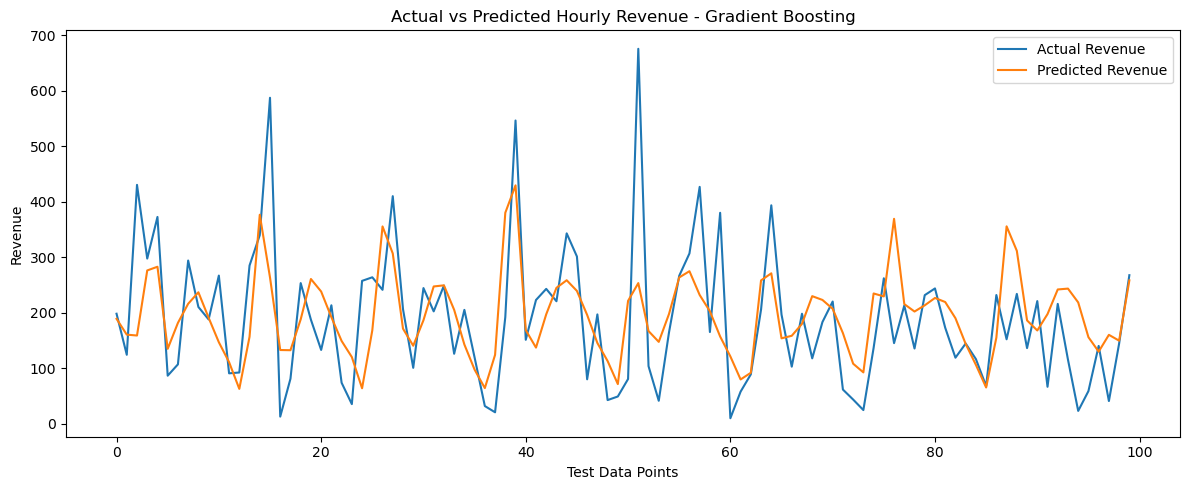

In [8]:
best_model_name = improved_results_df.sort_values("RMSE").iloc[0]["Model"]
best_model = improved_models[best_model_name]

best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label="Actual Revenue")
plt.plot(best_preds[:100], label="Predicted Revenue")
plt.title(f"Actual vs Predicted Hourly Revenue - {best_model_name}")
plt.xlabel("Test Data Points")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.savefig("../images/ml_actual_vs_predicted_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Importance

Feature importance is used to understand which features contributed most to the model's predictions.

This helps connect the machine learning model back to the business problem. If features such as hour, lunch period, weekend indicator, or lag revenue are important, it supports the earlier SQL and Power BI findings that sales are strongly affected by time-based demand patterns.

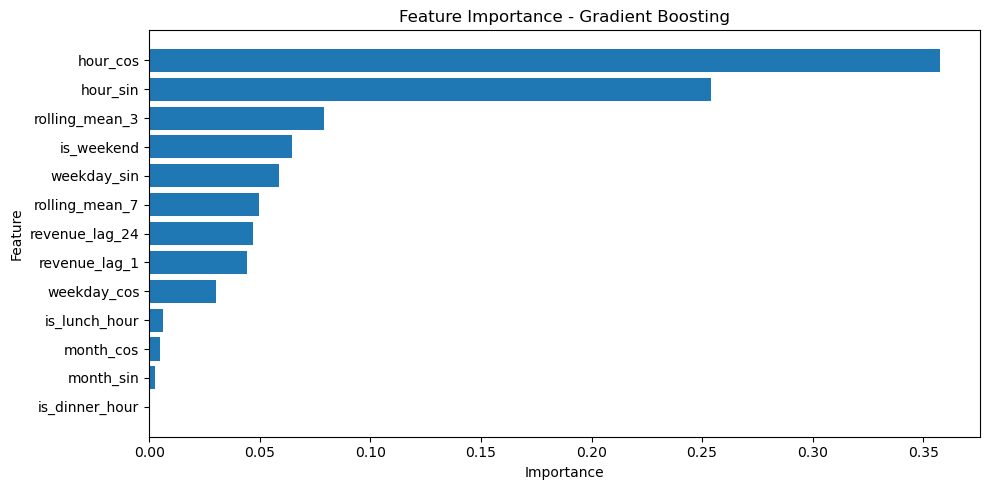

,Feature,Importance
4,hour_cos,0.357761
3,hour_sin,0.254091
11,rolling_mean_3,0.079206
0,is_weekend,0.064676
5,weekday_sin,0.058897
12,rolling_mean_7,0.049817
10,revenue_lag_24,0.047024
9,revenue_lag_1,0.044385
6,weekday_cos,0.030315
1,is_lunch_hour,0.006318


In [9]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("../images/ml_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()

    display(importance_df)
else:
    print(f"{best_model_name} does not provide feature importances.")

## Feature Importance Interpretation

The feature importance results show that cyclical hour features were the most important predictors of hourly revenue. This confirms that time of day plays a major role in pizza sales demand.

The rolling average features also contributed to the model, showing that recent sales behaviour helps predict near-future revenue.

The weekend and weekday features had moderate importance, which supports the earlier SQL and Power BI analysis showing different demand patterns between weekdays and weekends.

The dinner-hour feature had very low importance in the final model. This does not mean dinner periods are unimportant overall; it means that once hour-based cyclical features were included, the model already captured much of the dinner-time pattern through the hour variables.

## Business Conclusion

This modelling phase showed that hourly pizza revenue can be partially predicted using time-based and historical demand features.

The baseline model using only month, weekday, and hour had limited predictive power. After adding engineered features such as weekend indicators, lunch and dinner flags, cyclical time features, lag revenue, and rolling averages, the model was better able to capture demand patterns.

From a business perspective, the model can support operational planning by estimating expected revenue for different time periods. This can help the restaurant prepare staff, ingredients, and promotions more effectively.

However, the model still has limitations. The dataset does not include external factors such as weather, holidays, promotions, local events, delivery conditions, or customer-level information. Including these features could improve future prediction performance.

## Hyperparameter Tuning

After comparing multiple regression models, Gradient Boosting was selected as the best-performing model based on RMSE.

To improve its performance further, hyperparameter tuning was applied using GridSearchCV. Since this is time-based data, TimeSeriesSplit was used instead of random cross-validation to preserve the chronological order of observations.

In [11]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb_model = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

In [12]:
tuned_model = grid_search.best_estimator_

tuned_preds = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

tuned_results = pd.DataFrame({
    "Model": ["Tuned Gradient Boosting"],
    "MAE": [tuned_mae],
    "RMSE": [tuned_rmse],
    "R2": [tuned_r2]
})

tuned_results

,Model,MAE,RMSE,R2
0,Tuned Gradient Boosting,84.254614,109.616173,0.329372


In [13]:
untuned_best = improved_results_df[
    improved_results_df["Model"] == "Gradient Boosting"
]

tuning_comparison = pd.concat(
    [untuned_best, tuned_results],
    ignore_index=True
)

tuning_comparison

,Model,MAE,RMSE,R2
0,Gradient Boosting,84.105455,109.474418,0.331106
1,Tuned Gradient Boosting,84.254614,109.616173,0.329372


## Hyperparameter Tuning Results

Hyperparameter tuning was applied to the Gradient Boosting Regressor using TimeSeriesSplit. The goal was to check whether model performance could be improved after selecting Gradient Boosting as the best-performing model from the improved model comparison.

The tuned model produced very similar results to the untuned Gradient Boosting model. However, the untuned model performed slightly better on the final test set, with a lower RMSE and slightly higher R² score.

This shows that tuning does not always guarantee better performance on unseen data. The tuning process selects the best parameters based on cross-validation performance within the training data, but those parameters may not always generalize better to the test set.

Since the untuned Gradient Boosting model performed slightly better and is simpler, it was selected as the final model.